In [1]:
import os
import csv
import sys
import math
import random
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pandas as pd

from time import sleep
from collections import deque
from itertools import count
from typing import List

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from importnb import Notebook
with Notebook():
    from LabLatencyModel import LatencyModel, MultiDULatencyModel
    from LabCacheEngine import CacheEngineEnv, LruPolicy, SvcLruPolicy
    from LabUserTileRequest import UserTileRequestEvents
    from LabEnvWrapper import EnvWrapper

# sys.path.append(r'c:\Users\es25591\Workspace\CacheVideoPredict360\Sources')
sys.path.append('/home/eduardo/Workspace/CacheVideoPredict360/Sources')
from Common.Utils import save_training_results



In [2]:
# Check PyTorch GPU availability and basic operation
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using device: {torch.cuda.get_device_name(torch.cuda.current_device())}")
    x = torch.randn(2, 2, device="cuda")
    y = torch.randn(2, 2, device="cuda")
    print("Sample CUDA tensor sum:\n", (x + y))
else:
    print("GPU not detected; running on CPU.")

CUDA available: True
Using device: NVIDIA GeForce RTX 3050 6GB Laptop GPU
Sample CUDA tensor sum:
 tensor([[ 0.5666, -0.0337],
        [ 0.9014, -0.4352]], device='cuda:0')


In [3]:
class LSTM_DQN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, num_layers=1):
        super(LSTM_DQN, self).__init__()

        # Input size will now be (n_tiles + 1)
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, output_size)
    
    def forward(self, x):
            # x shape: (batch, seq_len, input_size)
            lstm_out, _ = self.lstm(x)
            
            # Take the output of the last time step
            last_out = lstm_out[:, -1, :]
            
            return self.fc(last_out)
        

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ReplayMemory:
    def __init__(self, capacity):
        self.memory = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        # state shape: (seq_len, input_size)
        self.memory.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        return random.sample(self.memory, batch_size)

    def __len__(self):
        return len(self.memory)
    
class DQNAgent:
    def __init__(
        self, 
        n_tiles, 
        seq_len, 
        learning_rate=1e-3, 
        gamma=0.99,
        batch_size=64,
        capacity=10000,
        epsilon_start=1.0,
        epsilon_min=0.05,
        epsilon_decay=0.995
    ):
        self.n_tiles = n_tiles
        self.gamma = gamma
        self.epsilon = epsilon_start
        self.epsilon_min = epsilon_min
        self.epsilon_decay = epsilon_decay
        
        # Initialize standard LSTM_DQN with the new input dimension
        self.policy_net = LSTM_DQN(n_tiles + 1, 32, n_tiles + 1).to(device)
        self.target_net = LSTM_DQN(n_tiles + 1, 32, n_tiles + 1).to(device)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()
        
        self.optimizer = optim.Adam(
            self.policy_net.parameters(), 
            lr=learning_rate
        )

        self.criterion = nn.MSELoss()
        self.memory = ReplayMemory(capacity=capacity)
        self.batch_size = batch_size

    def select_action(self, state):        
        if random.random() < self.epsilon:
            return random.randrange(self.n_tiles + 1), None
        else:
            with torch.no_grad():
                state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.policy_net(state_t)
                return q_values.argmax().item(), q_values.cpu().numpy()
                        
    def select_optimal_action(self, state):        
        with torch.no_grad():
            state_t = torch.FloatTensor(state).unsqueeze(0).to(device)
            q_values = self.policy_net(state_t)
            return q_values.argmax().item(), q_values.cpu().numpy()

    def train_step(self):
        if len(self.memory) < self.batch_size:
            return 0.0
        
        batch = self.memory.sample(self.batch_size)
        states, actions, rewards, next_states, dones = zip(*batch)

        # 1. Convert lists to Tensors (Directly, no tuple splitting needed)
        states_tensor = torch.FloatTensor(np.array(states)).to(device)
        actions_tensor = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards_tensor = torch.FloatTensor(rewards).to(device)
        next_states_tensor = torch.FloatTensor(np.array(next_states)).to(device)
        dones_tensor = torch.FloatTensor(np.array(dones, dtype=np.float32)).to(device)

        # --- Q-VALUE CALCULATION ---
        
        # ERROR WAS HERE: "q_values, _ =" -> "q_values ="
        q_values = self.policy_net(states_tensor)
        
        state_action_values = q_values.gather(1, actions_tensor).squeeze(1)

        with torch.no_grad():
            # ERROR WAS ALSO HERE: "next_q_values, _ =" -> "next_q_values ="
            next_q_values = self.target_net(next_states_tensor)
            
            next_state_values = next_q_values.max(1)[0]
            expected_state_action_values = rewards_tensor + (self.gamma * next_state_values * (1 - dones_tensor))

        loss = self.criterion(state_action_values, expected_state_action_values)
        
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()
        
        return loss.item()
    
    def update_target_network(self):
        self.target_net.load_state_dict(self.policy_net.state_dict())
        
    def update_epsilon(self):
        self.epsilon = max(self.epsilon_min, self.epsilon * self.epsilon_decay)

In [5]:
def index_to_fov_mask(center_idx, n):
    mask = np.zeros(n*n, dtype=int)    
    cy, cx = divmod(center_idx, n)
    
    for dy in [-1, 0, 1]:
        for dx in [-1, 0, 1]:
            ny, nx = cy + dy, cx + dx
            if 0 <= ny < n and 0 <= nx < n:
                mask[ny * n + nx] = 1
                
    return mask

In [6]:
from collections import defaultdict


if __name__ == "__main__":
    n_episodes = 200
    n_nodes = 10
    n_users = 100
    step_size = 10.0
    arrival_rate = 10.0  # users per second
    alpha = 2.0
    n_videos = 100
    n_gops = 60
    n_layers = 2
    n = 4
    n_tiles = n * n
    max_capacity = 100e6  # 100 MB

    # Hyperparameters for RL
    epsilon_start = 1.0
    epsilon_min = 0.005
    epsilon_decay = 0.985
    gamma = 0.99
    learning_rate = 1e-3
    batch_size = 64
    capacity = 10000
    window_len = 5  # LSTM sequence length (history window)

    # CPT parameters
    theta = 0.5
    lam = 3.7183

    # du_caches = [
    #     CacheEngineEnv(
    #         n_users=n_users,
    #         n_videos=n_videos,
    #         n_layers=n_layers,
    #         n_tiles=n_tiles,
    #         n_gops=n_gops,
    #         cache_capacity=max_capacity,
    #     ) for _ in range(n_nodes)
    # ]
    du_caches = []

    mec_cache = CacheEngineEnv(
        n_users=n_users,
        n_videos=n_videos,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n_gops=n_gops,
        cache_capacity=max_capacity,
        # policy=SvcLruPolicy(max_size=max_capacity)
    )

    # Initialize User Environment
    users_env = UserTileRequestEvents(
        n_nodes=n_nodes,
        n_users=n_users,
        n_videos=n_videos,
        n_gops=n_gops,
        n_layers=n_layers,
        n_tiles=n_tiles,
        n=n,
        users_viewport_tiles=None,
        requested_videos=None,
        users_arrivals=None,
        arrival_rate=arrival_rate
    )

    # Create latency model (replace numbers with your real config)
    P = n_nodes; max_U = n_users
    lat_model = MultiDULatencyModel(
        P=P, 
        max_U=max_U,
        R_M_D=80e6,  # 640 Mbps -> 80e6 B/s
        R_C_M=125e6, # 1 Gbps -> 125e6 B/s
        mu=2e7, 
        eta=2e5,
        B_pu_matrix=np.full((P, max_U), 40e6, dtype=float),    # 320 Mbps -> 40e6 B/s
        gamma_pu_matrix=np.full((P, max_U), 5.0, dtype=float), # SNRs
        rhoT_p=[0.2], 
        lambda_p=[0.05],
        du_fixed_delay=0.001,  # 1 ms
        mec_fixed_delay=0.005, # 5 ms
        cloud_fixed_delay=0.1  # 100 ms
    )

    env = EnvWrapper(
        n=n,
        n_layers=n_layers,
        users_env=users_env, 
        du_caches=du_caches,
        mec_cache=mec_cache,
        latency_model=lat_model,
        theta=theta,
        lam=lam
    )

    print(
        f"Experiment ===================\n"
        f"Total users: {n_users}\n"
        f"Cache capacity: {max_capacity}MB\n"
        f"Video matrix: {n_videos}x{n_layers}x{n*n}\n"
        f"==============================\n"
    )

    agent = DQNAgent(
        n_tiles=n_tiles, 
        seq_len=window_len,
        learning_rate=learning_rate,
        gamma=gamma,
        batch_size=batch_size,
        capacity=capacity,
        epsilon_start=epsilon_start,
        epsilon_min=epsilon_min,
        epsilon_decay=epsilon_decay
    )

    results = []
    scores = []
    cache_log = [] # Track active users per step

    for ep in range(n_episodes):

        obs, info = env.reset()

        user_histories = defaultdict(lambda: deque(maxlen=window_len))
        for u in range(n_users):
            for _ in range(window_len):
                # Fill with zeros: [0, 0, ..., 0] of size 17
                user_histories[u].append(np.zeros(n_tiles + 1))
                
        cache_hits = 0
        cache_misses = 0
        enhanced_layer_cache_hits = 0
        enhanced_layer_cache_misses = 0
        base_layer_cache_hits = 0
        base_layer_cache_misses = 0
        total_reward = 0.0
        avg_psnr = []

        for step in count():

            # --- AGENT ACTIONS ---
            reqs_state = info['users_requests']
            active_users = [
                (
                    req['u'], 
                    req['video'], 
                    req['gop'],
                    info['content_popularity'][0][req['video']] / sum(info['content_popularity'][0])
                ) for req in reqs_state if req['gop'] < n_gops
            ]

            actions = []
            user_action_indices = {}

            for u, video, gop, pop_val in active_users:
                state = np.array(user_histories[u])
                
                # Agent chooses center tile
                center_tile_idx, q_values = agent.select_action(state)
                user_action_indices[u] = center_tile_idx

                if center_tile_idx == n_tiles:
                    predicted_viewport = np.zeros(n*n, dtype=int)
                else:
                    predicted_viewport = index_to_fov_mask(center_idx=center_tile_idx, n=n)

                actions.append({
                    'user': u,
                    'gop': gop,
                    'video': video,
                    'tiles': predicted_viewport
                })

            # --- STEP ENV ---
            obs, rewards, done, info = env.step(actions)

            total_reward += float(rewards)
            enhanced_layer_cache_hits += info["enh_layer_cache_hits"]
            enhanced_layer_cache_misses += info["enh_layer_cache_misses"]
            base_layer_cache_hits += info["base_layer_cache_hits"]
            base_layer_cache_misses += info["base_layer_cache_misses"]
            avg_psnr.append(info.get("average_psnr", 0.0))

            step_reward = float(rewards) / max(1, len(active_users))

            # --- TRAINING / HISTORY UPDATE ---
            reqs_next_state = info['users_requests']

            for u, video, gop, pop_val in active_users:
                state = np.array(user_histories[u])

                next_pop_val = info['content_popularity'][0][video]
                next_pop_val = next_pop_val / sum(info['content_popularity'][0])
 
                target_indices = [
                    tile['tile'] 
                    for req in reqs_next_state 
                    if req['u'] == u 
                    for tile in req['tiles'] 
                    if tile['layer'] == 1
                ]
                actual_viewport = np.array([
                    1 if i in target_indices else 0 for i in range(n*n)
                ])

                dones = (gop == n_gops)
                
                # Concatenate [Mask (16) + Pop (1)] -> Result (17)
                next_feature_vec = np.concatenate([actual_viewport, [next_pop_val]])
                
                # Append to deque (automatically handles sliding window)
                user_histories[u].append(next_feature_vec)
                
                # --- STORE IN MEMORY ---
                next_state = np.array(user_histories[u])
                
                # Now we push clean arrays, no complex tuples!
                agent.memory.push(
                    state,  # Pushing the tuple (Seq, Pop)
                    user_action_indices[u],
                    step_reward,
                    next_state,
                    dones
                )
                
            agent.train_step()
            
            # print(f"Step {step}, Active Users: {len(active_users)}")
            # print(f"Request State: {reqs_state}")
            # print(f"Action: {actions}")
            # print(f"Next Request State: {reqs_next_state}")
            # print(
            #     f"Reward: {rewards}, "
            #     f"Cache Hits: {enhanced_layer_cache_hits + base_layer_cache_hits}, "
            #     f"Cache Misses: {enhanced_layer_cache_misses + base_layer_cache_misses}"
            # )
            # print("-----")
            
            ### Store cache utilization info ###
            # cache_utilization = info.get('cache_utilization', 0.0)
            # current_cache_capacity = info.get('cache_current_capacity', 0)
            
            # cache_log.append({
            #     'episode': ep,
            #     'step': step,
            #     'active_users': len(active_users),
            #     'cache_current_capacity': current_cache_capacity,
            #     'cache_utilization': cache_utilization
            # })
            
            # df_active_users = pd.DataFrame(cache_log)
            # df_active_users.to_csv(
            #     f'/home/eduardo/Workspace/CacheVideoPredict360/Results/cache_log_C{int(max_capacity/1e6)}MB_U{n_users}.csv',
            #     index=False
            # )
            ### End store cache utilization info ###
            
            if done:
                break

        # Update Target Network and Decay Epsilon
        if ep % 5 == 0:
            agent.update_target_network()

        agent.update_epsilon()

        avg_psnr = [x for x in avg_psnr if x != 0.0]

        cache_hits = enhanced_layer_cache_hits + base_layer_cache_hits
        cache_misses = enhanced_layer_cache_misses + base_layer_cache_misses

        print(
            f"Episode {ep+1}/{n_episodes}, "
            f"Total Reward: {total_reward:.2f}, "
            f"cache_hits: {cache_hits}, "
            f"cache_misses: {cache_misses}, "
            f"enh_layer_cache_hits: {enhanced_layer_cache_hits}, "
            f"enh_layer_cache_misses: {enhanced_layer_cache_misses}, "
            f"base_layer_cache_hits: {base_layer_cache_hits}, "
            f"base_layer_cache_misses: {base_layer_cache_misses}, "
            f"Average PSNR: {np.mean(avg_psnr) if avg_psnr else 0.0:.2f}, "
            f"Epsilon: {agent.epsilon:.4f}"
        )
        
        filename = (
            f"fov_predictor_ct_cp_E{n_episodes}_"
            f"U{n_users}_V{n_videos}_G{n_gops}_L{n_layers}_N{n}_"
            f"cap{int(max_capacity/1e6)}MB_AR{arrival_rate}.csv"
        )

        save_training_results(
            path_='/home/eduardo/Workspace/CacheVideoPredict360/Results',
            # path_=r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results',
            filename=filename,
            ep=ep,
            total_reward=total_reward,
            cache_hits=cache_hits,
            cache_misses=cache_misses,
            enhanced_layer_cache_hits=enhanced_layer_cache_hits,
            enhanced_layer_cache_misses=enhanced_layer_cache_misses,
            base_layer_cache_hits=base_layer_cache_hits,
            base_layer_cache_misses=base_layer_cache_misses,
            avg_psnr=np.mean(avg_psnr) if avg_psnr else 0.0,
            agent=agent
        )

        scores.append(total_reward)

        results.append({
            "episode": ep,
            "total_reward": total_reward,
            "cache_hits": cache_hits,
            "cache_misses": cache_misses,
        })


Experiment ===================
Total users: 100
Cache capacity: 100000000.0MB
Video matrix: 100x2x16

Episode 1/200, Total Reward: 5876.07, cache_hits: 106766, cache_misses: 14190, enh_layer_cache_hits: 12158, enh_layer_cache_misses: 12798, base_layer_cache_hits: 94608, base_layer_cache_misses: 1392, Average PSNR: 37.48, Epsilon: 0.9850
Episode 2/200, Total Reward: 6226.75, cache_hits: 107388, cache_misses: 13243, enh_layer_cache_hits: 12008, enh_layer_cache_misses: 12623, base_layer_cache_hits: 95380, base_layer_cache_misses: 620, Average PSNR: 37.75, Epsilon: 0.9702
Episode 3/200, Total Reward: 6268.66, cache_hits: 106744, cache_misses: 14094, enh_layer_cache_hits: 12210, enh_layer_cache_misses: 12628, base_layer_cache_hits: 94534, base_layer_cache_misses: 1466, Average PSNR: 37.79, Epsilon: 0.9557
Episode 4/200, Total Reward: 5429.73, cache_hits: 105530, cache_misses: 15214, enh_layer_cache_hits: 12157, enh_layer_cache_misses: 12587, base_layer_cache_hits: 93373, base_layer_cache_mi

In [7]:
# eval_episodes = 200

# results_eval = []
# scores_eval = []

# for ep in range(eval_episodes):
#     obs, info = env.reset()
#     user_histories = {
#         u: deque([np.zeros(n * n) for _ in range(window_len)], maxlen=window_len)
#         for u in range(n_users)
#     }

#     enhanced_hits = enhanced_misses = 0
#     base_hits = base_misses = 0
#     total_reward = 0.0
#     avg_psnr = []

#     for step in count():
#         reqs_state = info["users_requests"]
#         active_users = [
#             (req["u"], req["video"], req["gop"])
#             for req in reqs_state
#             if req["gop"] < n_gops
#         ]

#         actions = []
#         user_action_indices = {}

#         for u, video, gop in active_users:
#             cur_state_seq = np.array(user_histories[u])
#             center_idx, _ = agent.select_optimal_action(cur_state_seq)
#             user_action_indices[u] = center_idx

#             if center_idx == n_tiles:
#                 predicted_viewport = np.ones(n * n, dtype=int)
#             else:
#                 predicted_viewport = index_to_fov_mask(center_idx=center_idx, n=n)

#             actions.append({"user": u, "gop": gop, "video": video, "tiles": predicted_viewport})

#         obs, rewards, done, info = env.step(actions)

#         total_reward += float(rewards)
#         enhanced_hits += info["enh_layer_cache_hits"]
#         enhanced_misses += info["enh_layer_cache_misses"]
#         base_hits += info["base_layer_cache_hits"]
#         base_misses += info["base_layer_cache_misses"]
#         avg_psnr.append(info.get("average_psnr", 0.0))

#         step_reward = float(rewards) / max(1, len(active_users))
#         reqs_next_state = info["users_requests"]

#         for u, video, gop in active_users:
#             state = np.array(user_histories[u])
#             target_indices = [
#                 tile["tile"]
#                 for req in reqs_next_state
#                 if req["u"] == u
#                 for tile in req["tiles"]
#                 if tile["layer"] == 1
#             ]
#             actual_viewport = np.array([1 if i in target_indices else 0 for i in range(n * n)])

#             user_histories[u].append(actual_viewport)
#             next_state_seq = np.array(user_histories[u])
#             dones = gop == n_gops

#             agent.memory.push(state, user_action_indices[u], step_reward, next_state_seq, dones)

#         agent.train_step()

#         if done:
#             break

#     if ep % 5 == 0:
#         agent.update_target_network()

#     avg_psnr = [x for x in avg_psnr if x != 0.0]
#     cache_hits_ep = enhanced_hits + base_hits
#     cache_misses_ep = enhanced_misses + base_misses

#     print(
#         f"[Optimal] Episode {ep+1}/{eval_episodes} | "
#         f"Reward: {total_reward:.2f} | "
#         f"cache_hits: {cache_hits_ep} | cache_misses: {cache_misses_ep} | "
#         f"Enhanced(H/M): {enhanced_hits}/{enhanced_misses} | "
#         f"Base(H/M): {base_hits}/{base_misses} | "
#         f"Avg PSNR: {np.mean(avg_psnr) if avg_psnr else 0.0:.2f}"
#     )

#     scores_eval.append(total_reward)
#     results_eval.append(
#         {"episode": ep, "cache_hits": cache_hits_ep, "cache_misses": cache_misses_ep, "reward": total_reward}
#     )
    
#     filename_eval = (
#         f"fov_predictor_opt_E{eval_episodes}_"
#         f"U{n_users}_V{n_videos}_G{n_gops}_L{n_layers}_N{n}_"
#         f"cap{int(max_capacity/1e6)}MB_AR{arrival_rate}_eval.csv"
#     )
    
#     save_training_results(
#         path_='/home/eduardo/Workspace/CacheVideoPredict360/Results',
#         # path_=r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results',
#         filename=filename_eval,
#         ep=ep,
#         total_reward=total_reward,
#         cache_hits=cache_hits_ep,
#         cache_misses=cache_misses_ep,
#         enhanced_layer_cache_hits=enhanced_hits,
#         enhanced_layer_cache_misses=enhanced_misses,
#         base_layer_cache_hits=base_hits,
#         base_layer_cache_misses=base_misses,
#         avg_psnr=np.mean(avg_psnr) if avg_psnr else 0.0,
#         agent=agent
#     )

/tmp/ipykernel_466763/3657158268.py:17: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
/tmp/ipykernel_466763/3657158268.py:27: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
/tmp/ipykernel_466763/3657158268.py:37: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  axes[2].set_ylim(bottom=0)


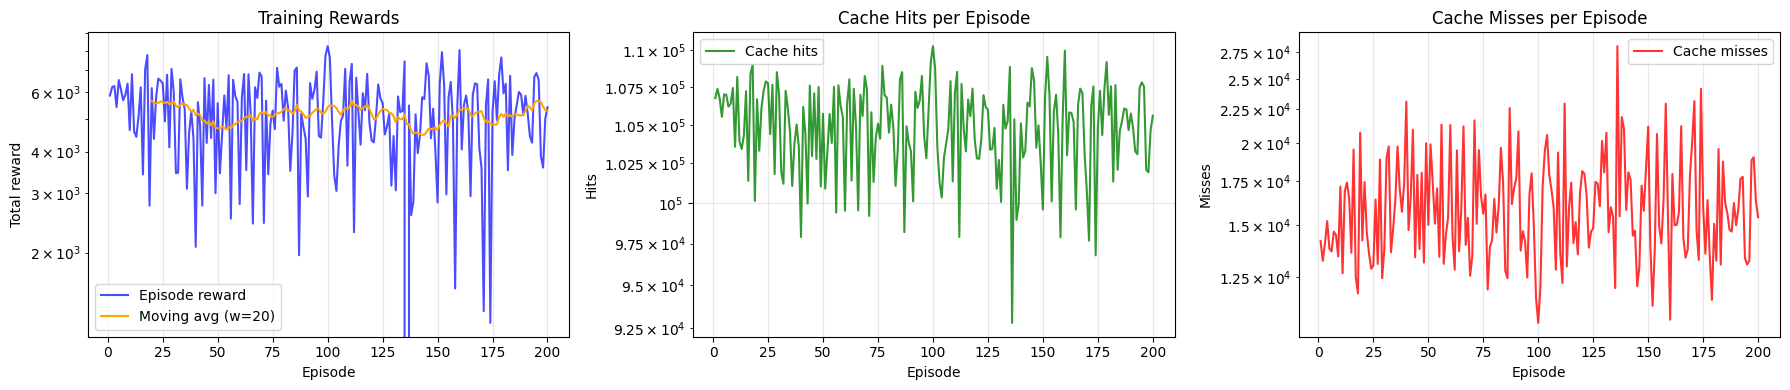

In [8]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# 1. Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_yscale('log') 
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_yscale('log') 
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)  # <--- Forces y-axis to start at 0
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# 3. Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_yscale('log')
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

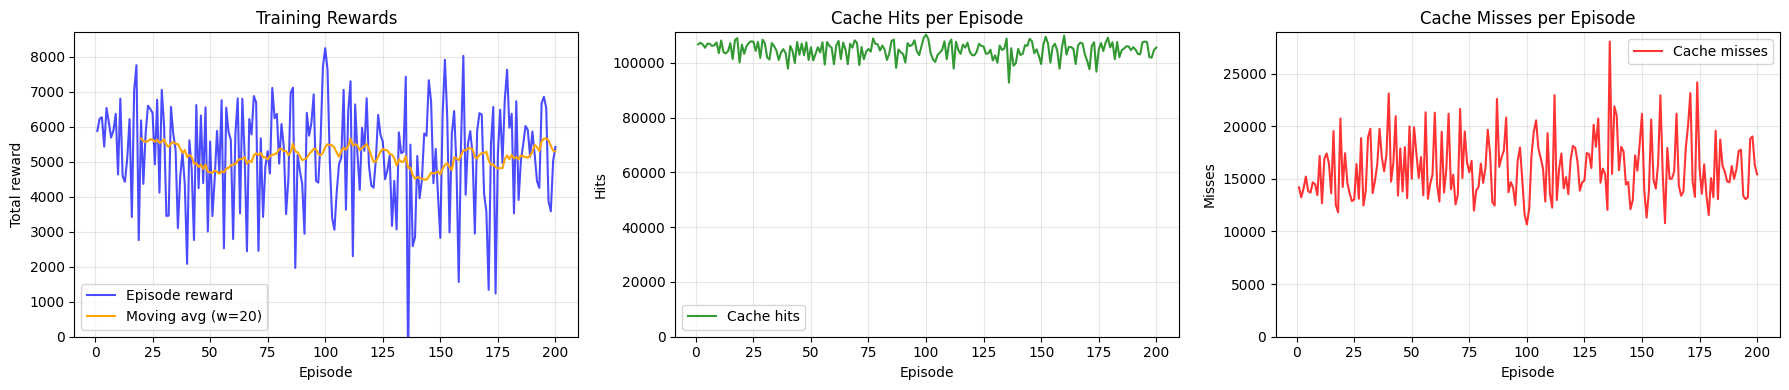

In [9]:
episodes = range(1, len(scores) + 1)
cache_hits_series = [r["cache_hits"] for r in results]
cache_misses_series = [r["cache_misses"] for r in results]

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharex=True)

# Rewards with moving average
axes[0].plot(episodes, scores, label="Episode reward", alpha=0.7, color="blue")
w = max(1, min(20, len(scores) // 10))
if w > 1:
    ma = [sum(scores[i - w:i]) / w for i in range(w, len(scores) + 1)]
    axes[0].plot(range(w, len(scores) + 1), ma, label=f"Moving avg (w={w})", color="orange")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Total reward")
axes[0].set_title("Training Rewards")
axes[0].set_ylim(bottom=0)
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Cache hits
axes[1].plot(episodes, cache_hits_series, label="Cache hits", color="green", alpha=0.8)
axes[1].set_title("Cache Hits per Episode")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Hits")
axes[1].set_ylim(bottom=0)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Cache misses
axes[2].plot(episodes, cache_misses_series, label="Cache misses", color="red", alpha=0.8)
axes[2].set_title("Cache Misses per Episode")
axes[2].set_xlabel("Episode")
axes[2].set_ylabel("Misses")
axes[2].set_ylim(bottom=0)
axes[2].grid(True, alpha=0.3)
axes[2].legend()

plt.tight_layout()
plt.show()

In [10]:
def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []
    rewards: List[float] = []
    avg_psnr: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
            "total_reward",
            "average_psnr"
        ]
        
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
                rewards.append(float(row["total_reward"]))
                avg_psnr.append(float(row["average_psnr"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, avg_psnr


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, psnr = read_results(csv_path)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]
    base_totals = [h + m for h, m in zip(base_hits, base_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]
    base_hit_rate = [safe_pct(h, t) for h, t in zip(base_hits, base_totals)]
    base_miss_rate = [safe_pct(m, t) for m, t in zip(base_misses, base_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)
    base_ylim = (0, 100)

    fig, axes = plt.subplots(3, 2, figsize=(18, 16))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="Enhanced hit rate (%)", color="blue", alpha=0.9)
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="Enhanced miss rate (%)", color="red", alpha=0.9)
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Base Layer: Hit rate
    axes[1, 0].plot(episodes, base_hit_rate, label="Base hit rate (%)", color="green", alpha=0.9)
    axes[1, 0].set_title("Base Layer Hit Rate")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Rate (%)")
    axes[1, 0].set_ylim(base_ylim)
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Base Layer: Miss rate
    axes[1, 1].plot(episodes, base_miss_rate, label="Base miss rate (%)", color="orange", alpha=0.9)
    axes[1, 1].set_title("Base Layer Miss Rate")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("Rate (%)")
    axes[1, 1].set_ylim(base_ylim)
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    # Reward title
    axes[2, 0].plot(episodes, rewards, label="Episode reward", color="purple", alpha=0.9)
    axes[2, 0].set_title("Episode Rewards")
    axes[2, 0].set_xlabel("Episode")
    axes[2, 0].set_ylabel("Reward")
    axes[2, 0].grid(True, alpha=0.3)
    axes[2, 0].legend()

    # Average PSNR
    axes[2, 1].plot(episodes, psnr, label="Average PSNR", color="brown", alpha=0.9)
    axes[2, 1].set_title("Average PSNR per Episode")
    axes[2, 1].set_xlabel("Episode")
    axes[2, 1].set_ylabel("PSNR (dB)")
    axes[2, 1].grid(True, alpha=0.3)
    axes[2, 1].legend()


    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    # csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    csv_filepath += r'\fov_predictor_U100_V100_G60_L2_N4_cap500MB_AR15.0.csv'
    
    out_path = None

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )

FileNotFoundError: CSV file not found: c:\Users\es25591\Workspace\CacheVideoPredict360\Results\fov_predictor_U100_V100_G60_L2_N4_cap500MB_AR15.0.csv

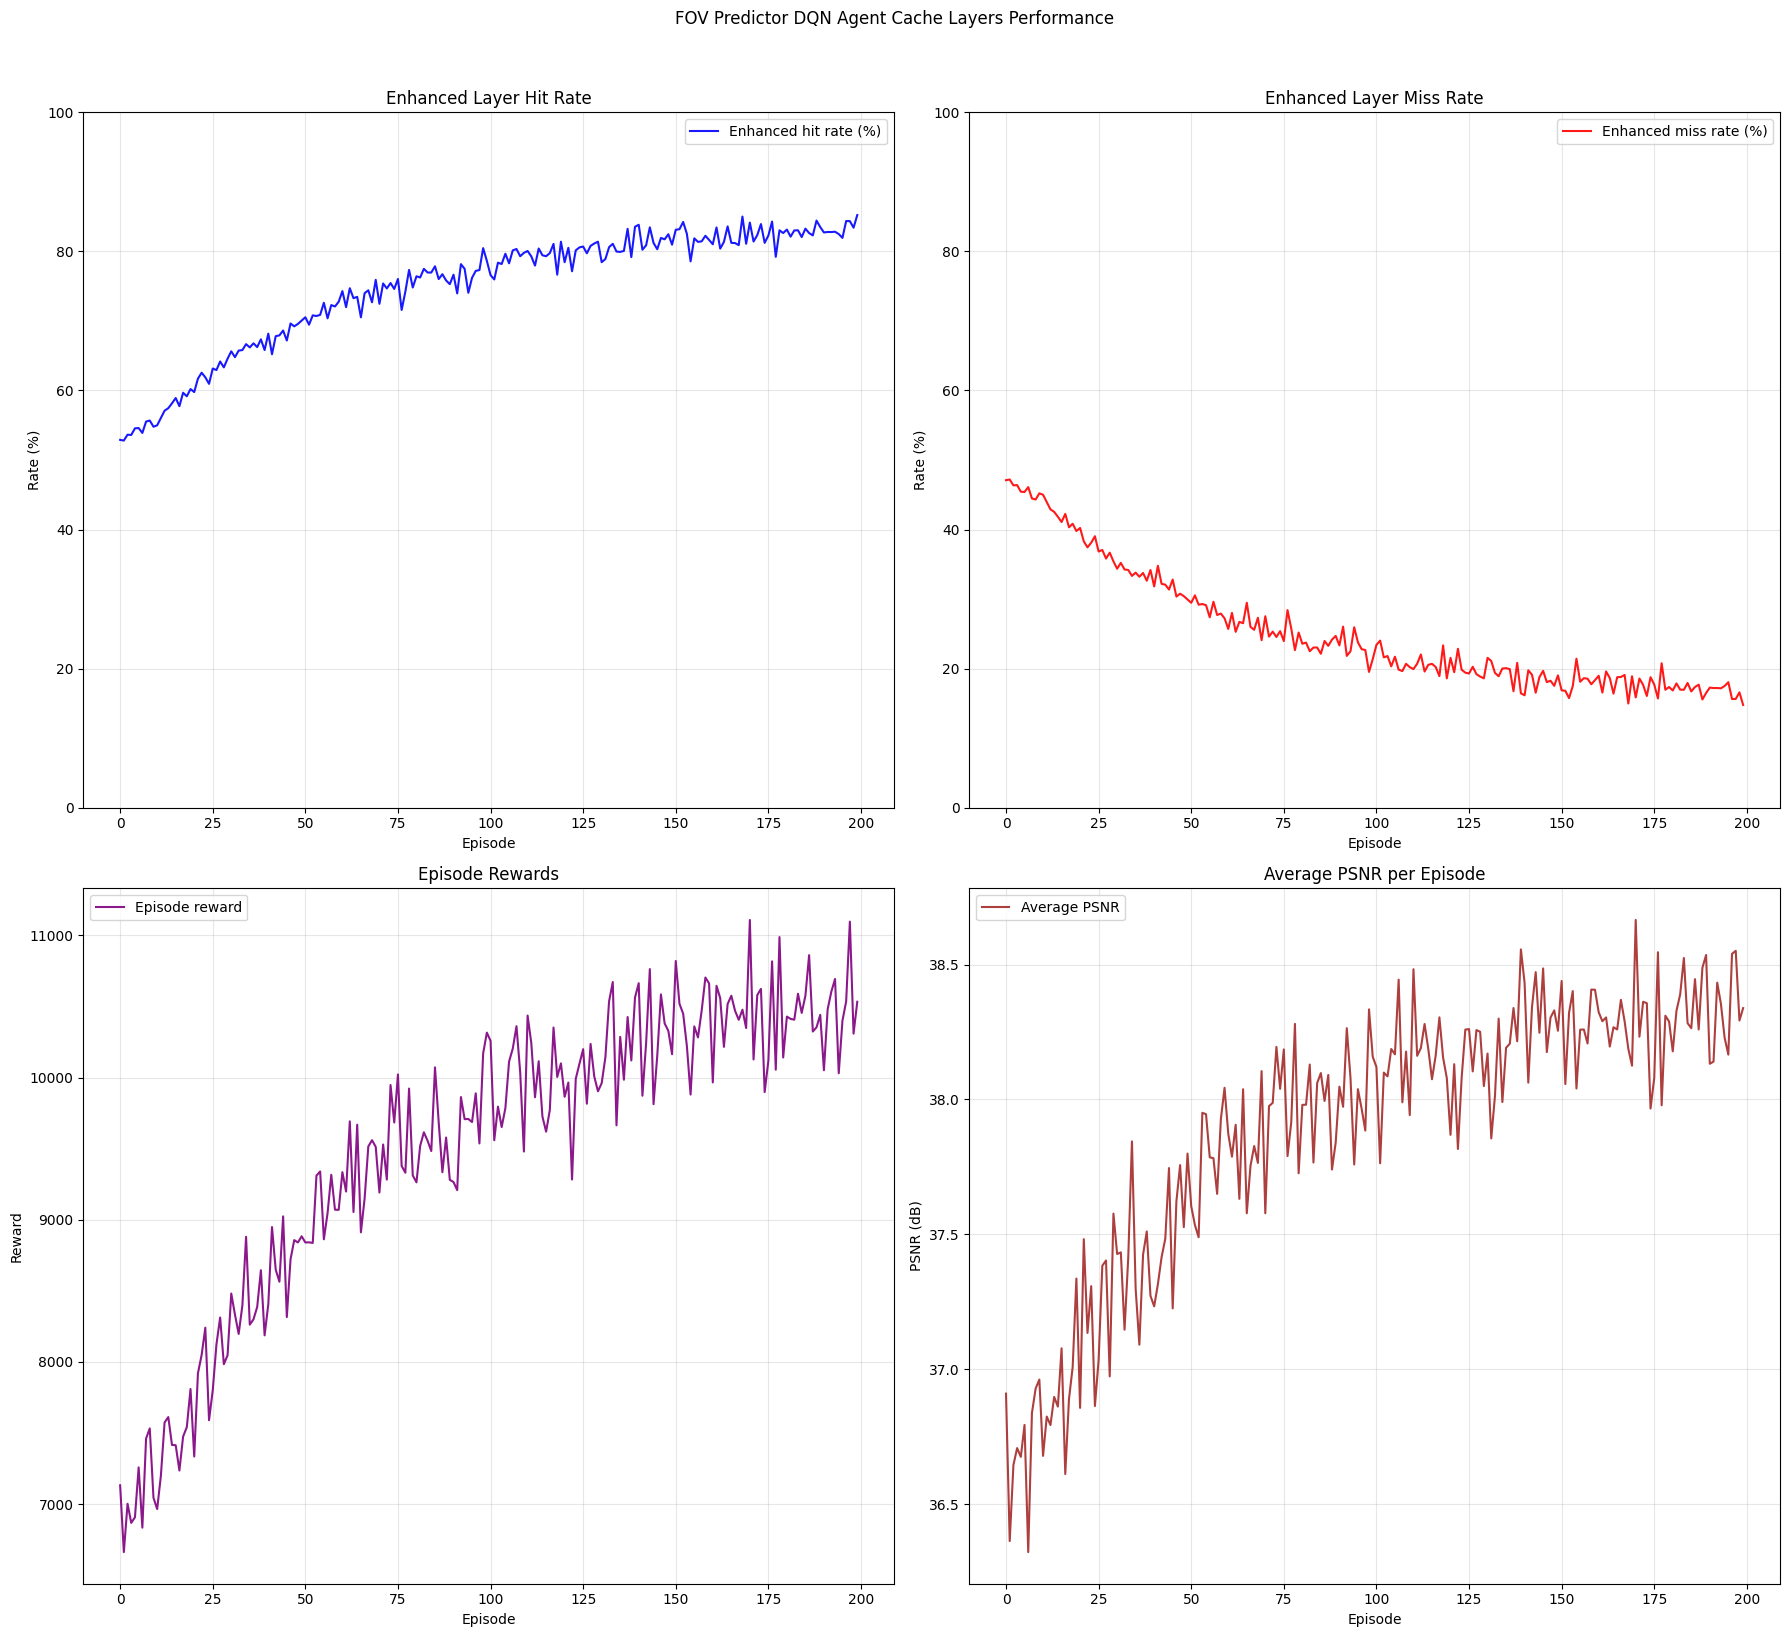

In [ ]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []
    rewards: List[float] = []
    avg_psnr: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
            "total_reward",
            "average_psnr"
        ]
        
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
                rewards.append(float(row["total_reward"]))
                avg_psnr.append(float(row["average_psnr"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, avg_psnr


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, psnr = read_results(csv_path)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)

    fig, axes = plt.subplots(2, 2, figsize=(18, 16))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="Enhanced hit rate (%)", color="blue", alpha=0.9)
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="Enhanced miss rate (%)", color="red", alpha=0.9)
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Reward title
    axes[1, 0].plot(episodes, rewards, label="Episode reward", color="purple", alpha=0.9)
    axes[1, 0].set_title("Episode Rewards")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Reward")
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Average PSNR
    axes[1, 1].plot(episodes, psnr, label="Average PSNR", color="brown", alpha=0.9)
    axes[1, 1].set_title("Average PSNR per Episode")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("PSNR (dB)")
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    # csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    csv_filepath += r'\fov_predictor_U100_V100_G60_L2_N4_cap500MB_AR15.0.csv'
    
    out_path = None

    title = "FOV Predictor DQN Agent Cache Layers Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )

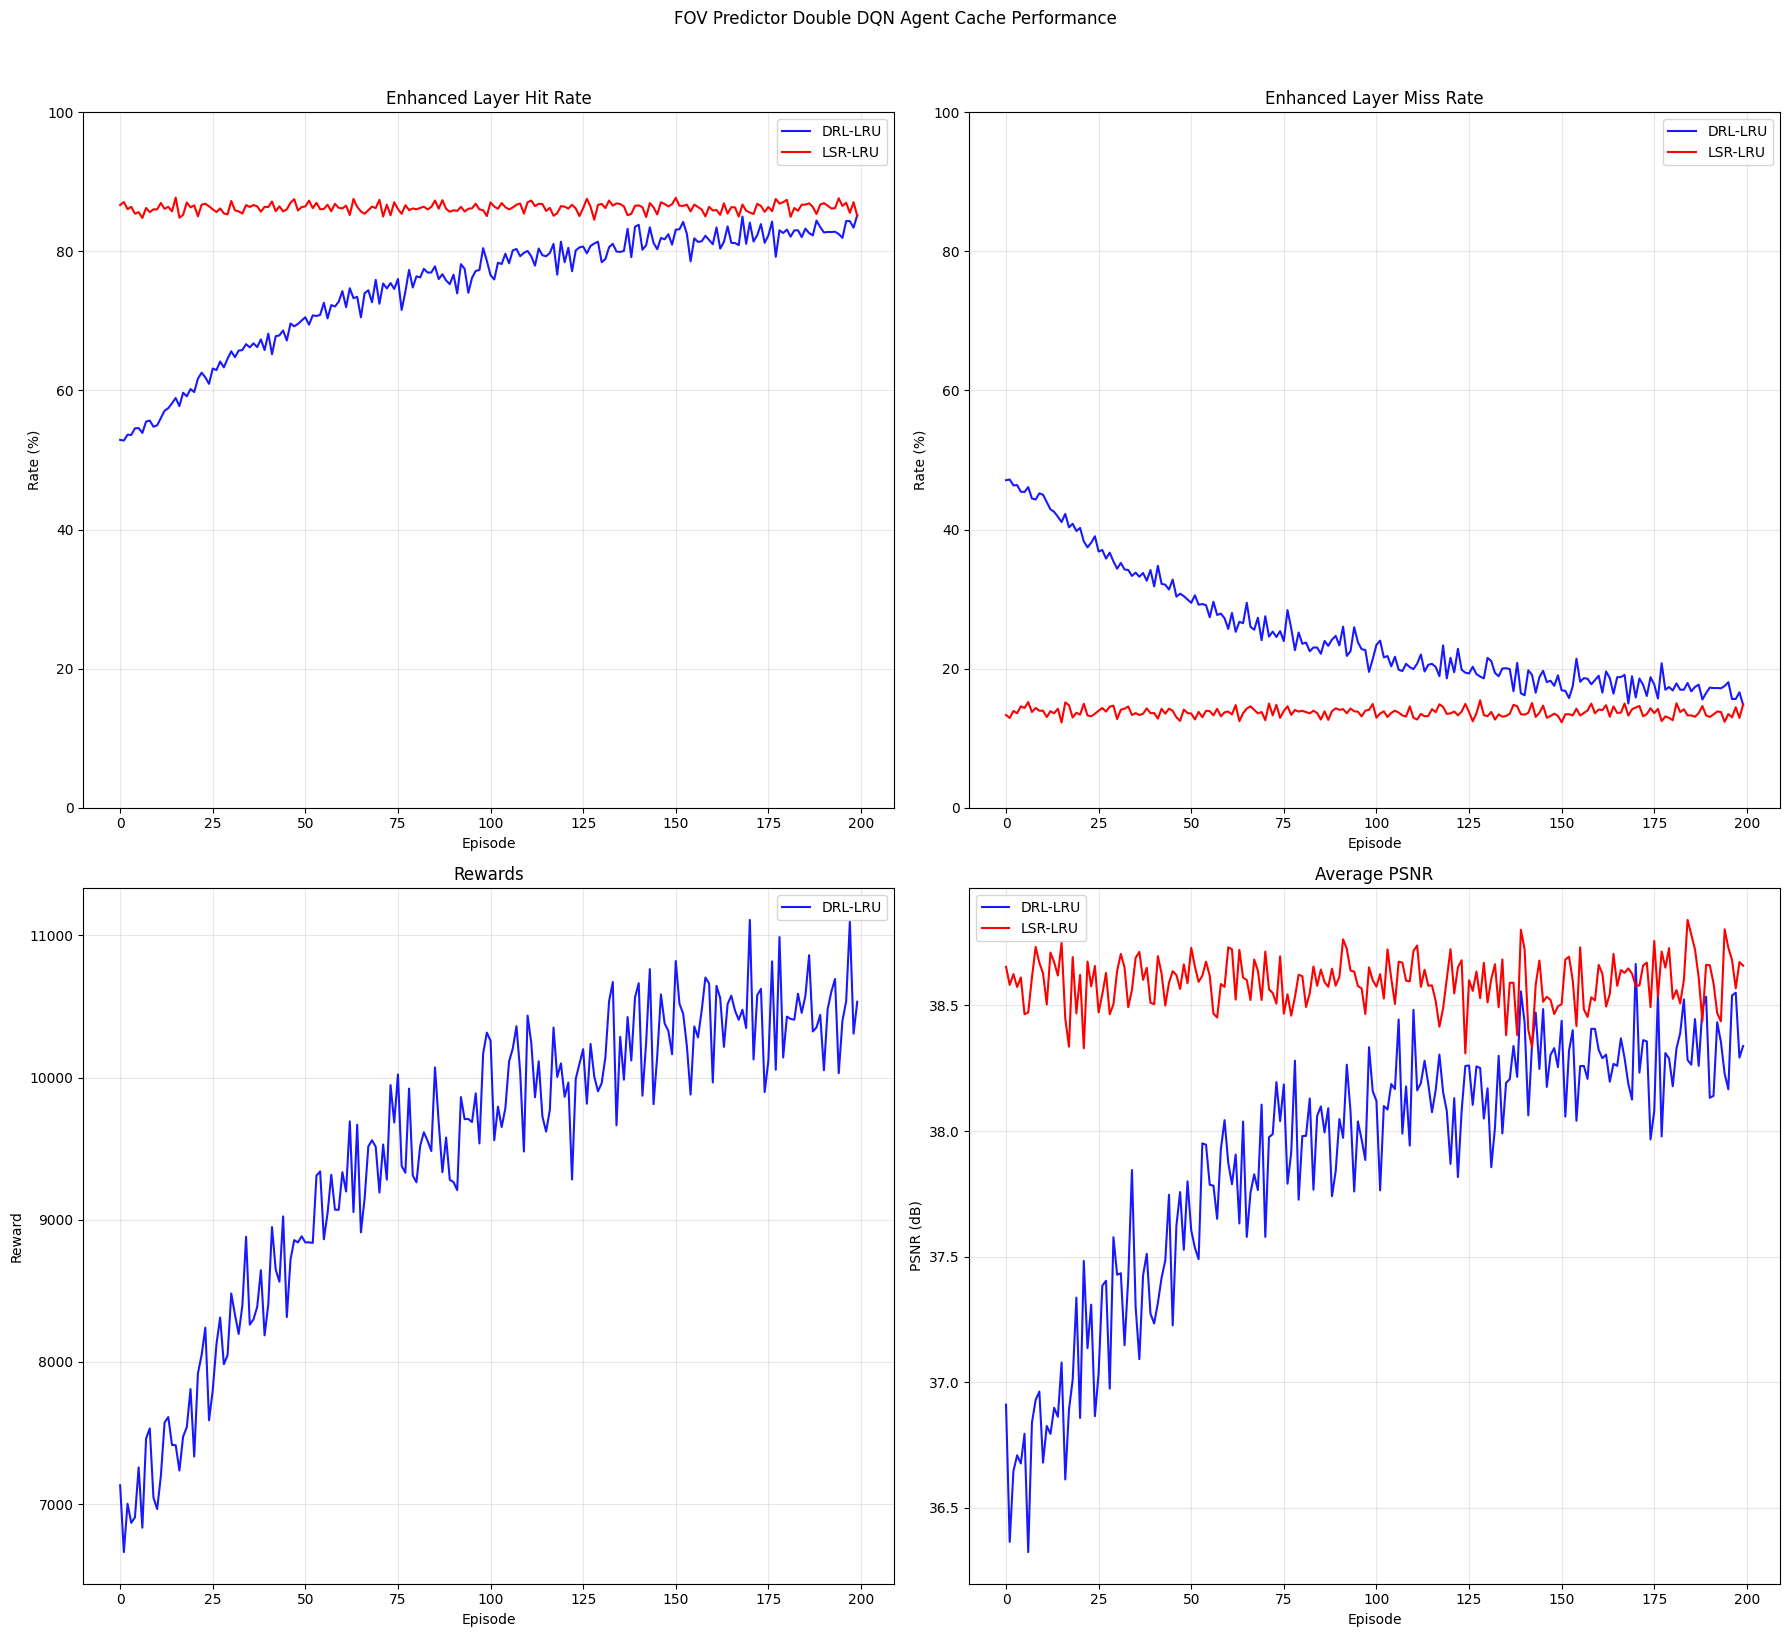

In [ ]:
from typing import List
import os

def read_results(csv_path: str):
    episodes: List[int] = []
    enhanced_hits: List[float] = []
    enhanced_misses: List[float] = []
    base_hits: List[float] = []
    base_misses: List[float] = []
    rewards: List[float] = []
    avg_psnr: List[float] = []

    if not os.path.exists(csv_path):
        raise FileNotFoundError(f"CSV file not found: {csv_path}")

    with open(csv_path, "r", newline="") as f:
        reader = csv.DictReader(f)
        required_cols = [
            "episode",
            "enhanced_layer_cache_hits",
            "enhanced_layer_cache_misses",
            "base_layer_cache_hits",
            "base_layer_cache_misses",
            "total_reward",
            "average_psnr"
        ]
        
        missing = [c for c in required_cols if c not in reader.fieldnames]
        if missing:
            raise ValueError(
                f"CSV missing required columns: {missing}. Found: {reader.fieldnames}"
            )

        for row in reader:
            try:
                episodes.append(int(row["episode"]))
                enhanced_hits.append(float(row["enhanced_layer_cache_hits"]))
                enhanced_misses.append(float(row["enhanced_layer_cache_misses"]))
                base_hits.append(float(row["base_layer_cache_hits"]))
                base_misses.append(float(row["base_layer_cache_misses"]))
                rewards.append(float(row["total_reward"]))
                avg_psnr.append(float(row["average_psnr"]))
            except (ValueError, KeyError):
                # skip malformed rows
                continue

    return episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, avg_psnr


def plot_cache_layers(
    csv_path: str,
    out_path: str | None = None,
    title: str | None = None,
):
    episodes, enhanced_hits, enhanced_misses, base_hits, base_misses, rewards, psnr = read_results(csv_path)

    csv_path_lsr = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    csv_path_lsr += r'\fov_lsr_U100_V100_G60_L2_N4_cap500MB_AR15.csv'

    episodes_lsr, enhanced_hits_lsr, enhanced_misses_lsr, base_hits_lsr, base_misses_lsr, rewards_lsr, psnr_lsr = read_results(csv_path_lsr)

    # Compute per-episode percentages
    def safe_pct(num, den):
        return 0.0 if den == 0 else 100.0 * num / den

    enh_totals = [h + m for h, m in zip(enhanced_hits, enhanced_misses)]

    enh_hit_rate = [safe_pct(h, t) for h, t in zip(enhanced_hits, enh_totals)]
    enh_miss_rate = [safe_pct(m, t) for m, t in zip(enhanced_misses, enh_totals)]

    # Shared y-lims per layer type (percentages)
    enh_ylim = (0, 100)

    fig, axes = plt.subplots(2, 2, figsize=(18, 16))

    # Enhanced Layer: Hit rate
    axes[0, 0].plot(episodes, enh_hit_rate, label="DRL-LRU", color="blue", alpha=0.9)
    axes[0, 0].plot(episodes_lsr, [safe_pct(h, h + m) for h, m in zip(enhanced_hits_lsr, enhanced_misses_lsr)], label="LSR-LRU", color="red")
    axes[0, 0].set_title("Enhanced Layer Hit Rate")
    axes[0, 0].set_xlabel("Episode")
    axes[0, 0].set_ylabel("Rate (%)")
    axes[0, 0].set_ylim(enh_ylim)
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()

    # Enhanced Layer: Miss rate
    axes[0, 1].plot(episodes, enh_miss_rate, label="DRL-LRU", color="blue", alpha=0.9)
    axes[0, 1].plot(episodes_lsr, [safe_pct(m, h + m) for h, m in zip(enhanced_hits_lsr, enhanced_misses_lsr)], label="LSR-LRU", color="red")
    axes[0, 1].set_title("Enhanced Layer Miss Rate")
    axes[0, 1].set_xlabel("Episode")
    axes[0, 1].set_ylabel("Rate (%)")
    axes[0, 1].set_ylim(enh_ylim)
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].legend()

    # Reward title
    axes[1, 0].plot(episodes, rewards, label="DRL-LRU", color="blue", alpha=0.9)
    axes[1, 0].set_title("Rewards")
    axes[1, 0].set_xlabel("Episode")
    axes[1, 0].set_ylabel("Reward")
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()

    # Average PSNR
    axes[1, 1].plot(episodes, psnr, label="DRL-LRU", color="blue", alpha=0.9)
    axes[1, 1].plot(episodes_lsr, psnr_lsr, label="LSR-LRU", color="red")
    axes[1, 1].set_title("Average PSNR")
    axes[1, 1].set_xlabel("Episode")
    axes[1, 1].set_ylabel("PSNR (dB)")
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].legend()

    if title:
        fig.suptitle(title, y=1.02)
    plt.tight_layout()

    if out_path:
        plt.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.show()


if __name__ == "__main__":
    # csv_filepath = '/home/eduardo/Workspace/CacheVideoPredict360/Results'
    csv_filepath = r'c:\Users\es25591\Workspace\CacheVideoPredict360\Results'
    csv_filepath += r'\fov_predictor_U100_V100_G60_L2_N4_cap500MB_AR15.csv'
    
    out_path = None

    title = "FOV Predictor Double DQN Agent Cache Performance"

    plot_cache_layers(
        csv_filepath, 
        out_path=None, 
        title=title
    )